In [1]:
from functools import partial

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import optimize
from scipy.ndimage import convolve
from tqdm import tqdm

from spectrumlab.backgrounds.asymmetric_least_squares_background import AsymmetricLeastSquaresBackgroundConfig, AsymmetricLeastSquaresBackgroundModel
from spectrumlab.detectors import Detector
from spectrumlab.noises import ConstantNoise
from spectrumlab.peaks.analyte_peaks.shapes import PeakShape
from spectrumlab.peaks.analyte_peaks.shapes.retrieve_shape import retrieve_shape_from_spectrum
from spectrumlab.peaks.blink_peaks import DraftBlinksConfig, draft_blinks
from spectrumlab.picture.colors import COLOR
from spectrumlab.spectra import EmittedSpectrum
from spectrumlab.types import Array, Number, R

from spectrumlab_emulations.apertures import Aperture, RectangularApertureShape
from spectrumlab_emulations.apparatus import Apparatus, VoigtApparatusShape
from spectrumlab_emulations.experiments.spectra_emulation import RandomPeakExperiment, RandomPeakExperimentConfig


In [2]:
N_NUMBERS = 2048
N_FRAMES = 1
N_ITERS = 250

EXPOSURE = 100

SHAPE = VoigtApparatusShape(
    width=28,
    asymmetry=+0.1,
    ratio=0.1,
)

MU = -1
SIGMA = .5

ALPHA = 0.001


verbose = True
show = True

In [3]:
def transformer(
    intensity: Array[R],
    background: Array[R],
    alpha: float = 0,
) -> Array[R]:
    assert len(intensity) == len(background)

    number = np.arange(len(intensity))
    index_even = number % 2 == 0
    index_odd = number % 2 == 1

    value = intensity.copy() + background.copy()
    value[index_even] = value[index_even] * (1 - alpha/2)
    value[index_odd] = value[index_odd] * (1 + alpha/2)
    return value


In [4]:
detector = Detector.BLPP2000
position = np.random.uniform(0, N_NUMBERS, size=(N_ITERS,))
intensity = 10**np.random.normal(MU, SIGMA, size=(N_ITERS,))

experiment = RandomPeakExperiment(
    config=RandomPeakExperimentConfig(
        n_numbers=N_NUMBERS,
        n_frames=N_FRAMES,

        detector=detector,
        apparatus=Apparatus(
            detector=detector,
            shape=SHAPE,
        ),
        aperture=Aperture(
            detector=detector,
            shape=RectangularApertureShape(),
        ),

        exposure=EXPOSURE,
        position=position,
        intensity=intensity,
    ),
)
experiment = experiment.setup(
    # seed=42,
)

In [5]:
scale = 1
number = np.arange(N_NUMBERS)


background_true = np.zeros(N_NUMBERS, dtype=float) + scale*1
for amplitude, mu, sigma in [
    (10, 2500, 75),
    (6, 600, 125),
    (4, 1400, 75),
    (3, 1700, 200),
]:
    line = scale * amplitude * np.exp(-((number - mu)**2) / (2 * sigma**2))
    background_true += line


In [6]:
unicorn = experiment.run(
    is_noised=False,
    transformer=partial(transformer, background=background_true),
)
spectrum = EmittedSpectrum(
    intensity=np.array([
        experiment.run(
            is_noised=True,
            transformer=partial(transformer, alpha=ALPHA, background=background_true),
        ).intensity
        for _ in range(100)
    ]),
)

In [7]:
%matplotlib widget

model = AsymmetricLeastSquaresBackgroundModel(
    config=AsymmetricLeastSquaresBackgroundConfig(
        lam=5e+4,
        p=1e-3,
    ),
)
background_hat = model.fit(
    spectrum=spectrum,
)


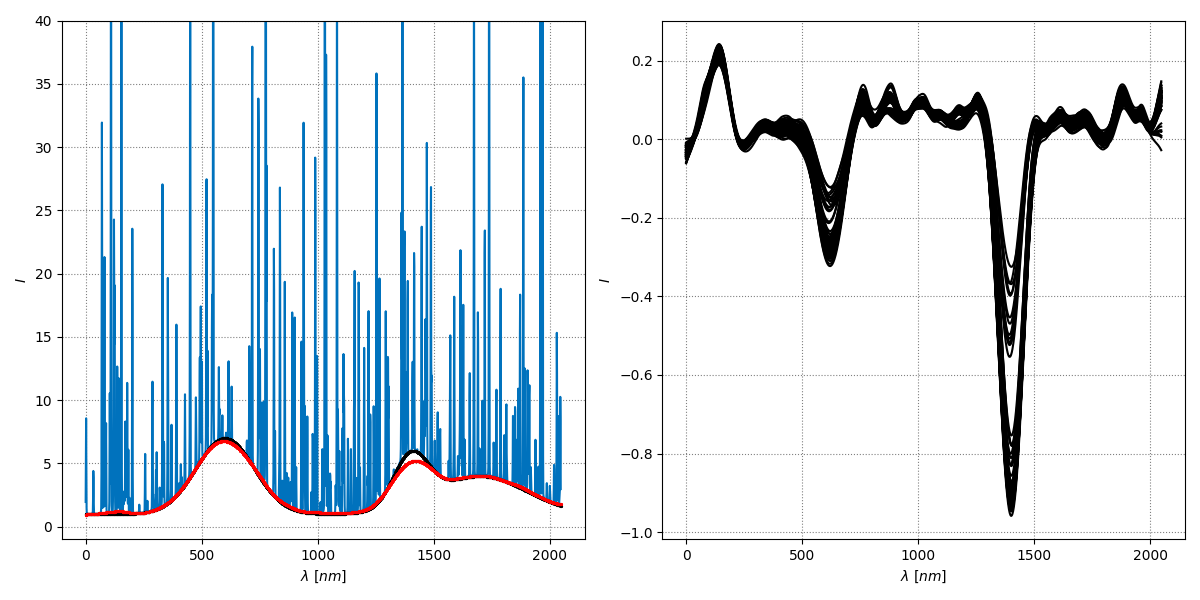

In [8]:

if show:
    fig, (ax_left, ax_right) = plt.subplots(ncols=2, figsize=(12, 6), tight_layout=True)

    ax_left.plot(
        spectrum.wavelength,
        np.mean(spectrum.intensity, axis=0),
        color=COLOR['blue'], alpha=1,
    )
    # ax_left.plot(
    #     spectrum.wavelength[mask],
    #     spectrum.intensity[mask],
    #     linestyle='none', color='red', alpha=1,
    #     marker='.', markersize=5,
    # )
    # ax_left.plot(
    #     spectrum.wavelength,
    #     background_hat_v0,
    #     linestyle=':', color='black', alpha=1,
    # )
    # ax_left.plot(
    #     spectrum.wavelength[mask],
    #     spectrum.intensity[mask],
    #     linestyle='none', color='red', alpha=1,
    #     marker='.', markersize=5,
    # )
    # ax_left.plot(
    #     spectrum.wavelength,
    #     background_hat_v0 + background_hat_v1,
    #     color='black', alpha=1,
    # )
    # ax_left.plot(
    #     spectrum.wavelength,
    #     (background_hat_v0 + background_hat_v1) - background_true,
    #     linestyle='none', color='black', alpha=1,
    #     marker='.', markersize=2.5,
    # )
    # ax_left.plot(
    #     spectrum.wavelength,
    #     background_hat.intensity - background_true,
    #     linestyle='none', color='black', alpha=1,
    #     marker='.', markersize=2.5,
    # )
    ax_left.plot(
        spectrum.wavelength,
        background_true,
        linestyle='none', color='black', alpha=1,
        marker='.', markersize=2.5,
    )
    ax_left.plot(
        spectrum.wavelength,
        np.mean(background_hat.intensity, axis=0),
        linestyle='none', color='red', alpha=1,
        marker='.', markersize=2.5,
    )
    ax_left.set_ylim([-1, 40])
    ax_left.set_xlabel(r'$\lambda$ [$nm$]')
    ax_left.set_ylabel(r'$I$')
    ax_left.grid(color='grey', linestyle=':')

    # ax_right.plot(
    #     spectrum.wavelength,
    #     100 * (background_hat_v0 - background_true) / background_true,
    #     linestyle=':', color='black', alpha=1,
    # )
    # ax_right.plot(
    #     spectrum.wavelength,
    #     100 * ((background_hat_v0 + background_hat_v1) - background_true) / background_true,
    #     color='black', alpha=1,
    # )
    for t in range(100):
        ax_right.plot(
            spectrum.wavelength,
            (background_hat.intensity[t, :] - background_true),
            color='black', alpha=1,
        )
    ax_right.set_xlabel(r'$\lambda$ [$nm$]')
    ax_right.set_ylabel(r'$I$')
    ax_right.grid(color='grey', linestyle=':')

    plt.show()
